<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# TS3: Análisis de Fourier: FFT, desparramo, interpolación y ventaneo
#### Sofía Makkos

#### Introducción

En el presente trabajo se estudiarán los efectos del desparramo espectral (spectral leakage) y del zero padding. Para el primero, se buscará utilizar frecuencias de la señal utilizada que no coincidan con alguna de los bins, de manera que la energía no podrá concentrarse en un único punto, y se distribuirá sobre los bins vecinos. El segundo fenómeno permitirá mejorar la resolución de cada frecuencia, agregando un vector nulo a la señal.

Por otro lado, también se corroborará la potencia de cada señal previo y posterior a que se les aplique la Fast Fourier Transform. Para ello, se empleará la identidad de Parseval:
\begin{equation}
\sum_{i=1}^{N-1}|x[n]|^2=\frac{1}{N}\sum_{i=1}^{N-1}|X[k]|^2
\end{equation}
Estas igualdades llevarán a un resultado energético, de modo que se aplicará $\frac{1}{N}$ a ambos lados de la fórmula, consiguiendo así la potencia:
\begin{equation}
\frac{1}{N}\sum_{i=1}^{N-1}|x[n]|^2=\frac{1}{N^2}\sum_{i=1}^{N-1}|X[k]|^2
\end{equation}

#### Desarrollo

Implemento librerías, inicializo variables y defino las funciones generales a emplear

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
#%%
N=1000
k0=N/4
fs=1000
f0=k0*fs/N
#%%
def mi_funcion_sen( vmax = np.sqrt(2), dc = 0, ff = 1, ph=0, nn = N, fs = fs):
    tt=np.arange(0.0, N/fs, 1/fs)
    xx=vmax*np.sin(2*np.pi*ff*tt +ph)+dc
    return tt, xx
def fastfouriertrans (xx, N, fs):
    fftxx = fft(xx)
    #fftxx = fftxx[:N//2]
    freq = fftfreq(N,1/fs)
    freq = freq[:N//2]
    fftxx_abs = np.abs(fftxx)
    return freq, fftxx_abs

La amplitud *Vmax* será de $\sqrt2$, y así, contará con una potencia de 1W. En la función *fastfouriertrans* se omitió la partición de la variable *fftxx*, ya que esto impediría calcular correctamente la potencia posterior al aplicar la FFT. Esto luego será indicado al momento de graficar.

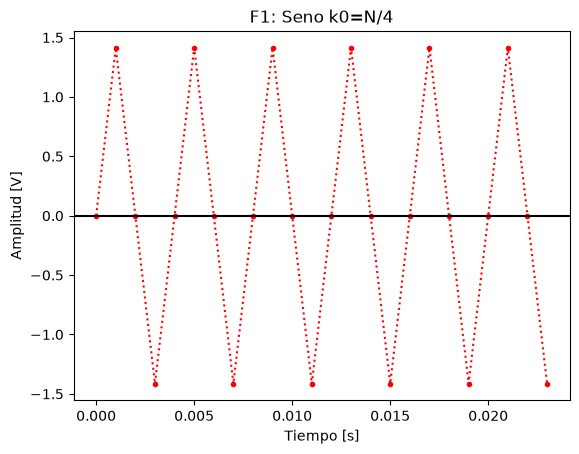

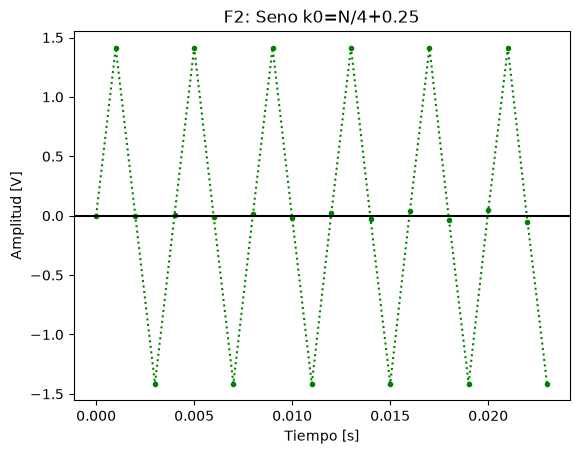

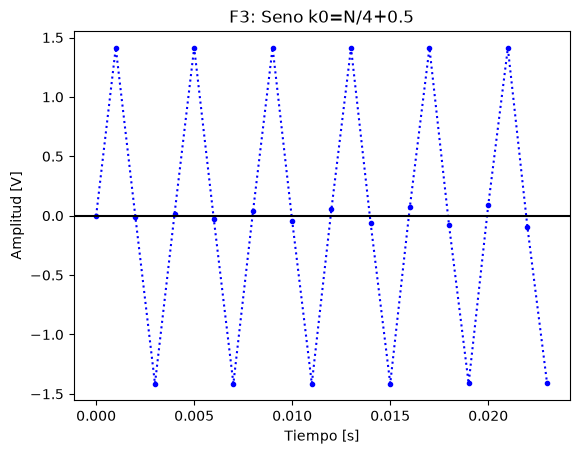

In [2]:
tt1, sen1=mi_funcion_sen(ff=f0)

plt.figure(1)
plt.plot(tt1[:24],sen1[:24], ":.",color="red")
plt.title("F1: Seno k0=N/4")
plt.ylabel("Amplitud [V]")
plt.xlabel("Tiempo [s]")
plt.axhline(0,color="black")

k0=N/4+0.25
f0=k0*fs/N
tt2, sen2=mi_funcion_sen(ff=f0)

plt.figure(2)
plt.plot(tt2[:24],sen2[:24], ":.",color="green")
plt.title("F2: Seno k0=N/4+0.25")
plt.ylabel("Amplitud [V]")
plt.xlabel("Tiempo [s]")
plt.axhline(0,color="black")

k0=N/4+0.5
f0=k0*fs/N
tt3, sen3=mi_funcion_sen(ff=f0)

plt.figure(3)
plt.plot(tt3[:24],sen3[:24], ":.",color="blue")
plt.title("F3: Seno k0=N/4+0.5")
plt.ylabel("Amplitud [V]")
plt.xlabel("Tiempo [s]")
plt.axhline(0,color="black")

Entre las tres figuras presentadas hay cambios sutiles de frecuencia. A través de la siguiente fórmula, en la cual el *k0* determina la frecuencia de la señal.
\begin{equation}
f_0=k_0\frac{f_s}{N}=k_0\bigtriangleup{f}
\end{equation}
Tomando el primer k0 como N/4, nos encontramos a la mitad de Nyquist. Así, se consigue que cada período cuente con 4 puntos. En los gráficos se puede observar esto, a lo largo de 6 períodos, ya que en la función *plt.plot* se le indicó a las variables la consideración de hasta 24 puntos ($4_{puntos}*6_{períodos}$). Luego, los otros dos *k0* estarán desfasados ligeramente en comparación al primero. A demás, a medida que avanza cada período, los puntos se alejan cada vez más del eje de abscisas, consecuencia de su irregularidad con la cantidad de muestras N.

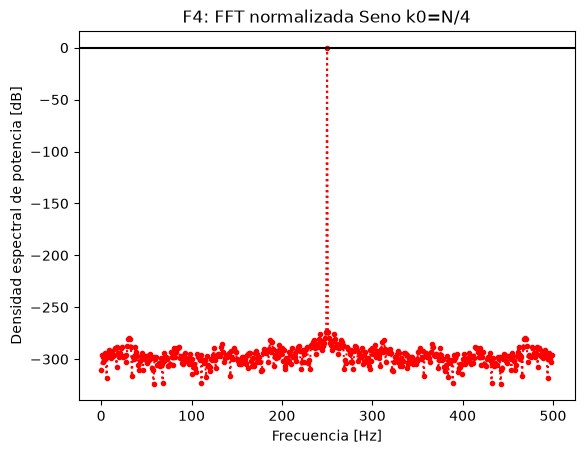

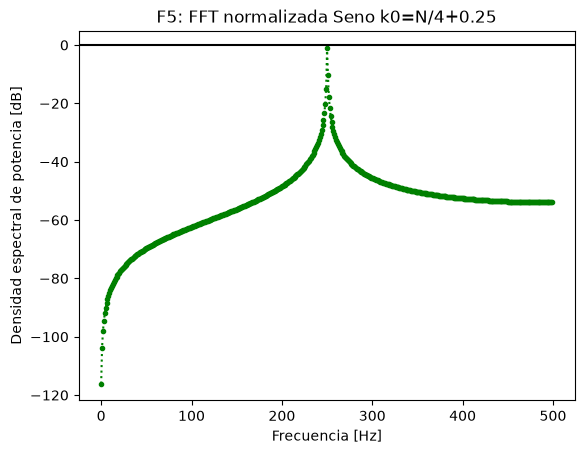

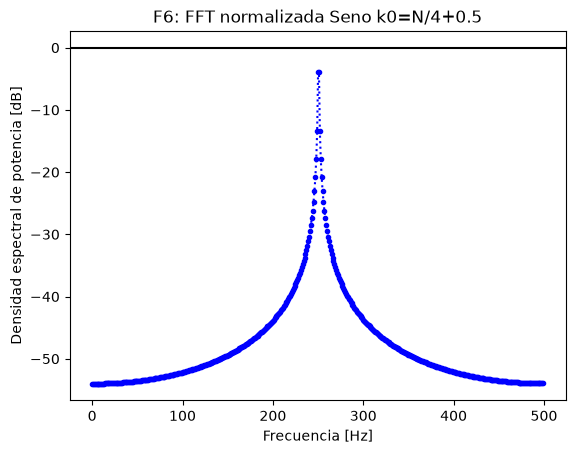

In [3]:
freq1, fftsen1_abs=fastfouriertrans(sen1, N, fs)
freq2, fftsen2_abs=fastfouriertrans(sen2, N, fs)
freq3, fftsen3_abs=fastfouriertrans(sen3, N, fs)

ref=np.max(fftsen1_abs)
fftsen1_abs_dB=20*np.log10(fftsen1_abs/ref)
fftsen2_abs_dB=20*np.log10(fftsen2_abs/ref)
fftsen3_abs_dB=20*np.log10(fftsen3_abs/ref)

plt.figure(4)
plt.plot(freq1, fftsen1_abs_dB[:N//2],":.", color="red")
plt.title("F4: FFT normalizada Seno k0=N/4")
plt.ylabel("Densidad espectral de potencia [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.axhline(0,color="black")
plt.figure(5)
plt.plot(freq2, fftsen2_abs_dB[:N//2],":.", color="green")
plt.title("F5: FFT normalizada Seno k0=N/4+0.25")
plt.ylabel("Densidad espectral de potencia [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.axhline(0,color="black")
plt.figure(6)
plt.plot(freq3, fftsen3_abs_dB[:N//2],":.", color="blue")
plt.title("F6: FFT normalizada Seno k0=N/4+0.5")
plt.ylabel("Densidad espectral de potencia [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.axhline(0,color="black")

A cada sinusoidal se le aplicó la FFT, y luego se realizó la conversión a desibeles, tomando como referencia la primer señal. Al momento de graficar, se le indicó a cada una que se tomen la mitad de los puntos mediante [:N//2].

Es destacable cómo fourier provocó grandes distinciones en los gráficos en comparación con las primeras figuras. Debido a que la frecuencia no concuerda con la cantidad de muestras (*N*=1000), la potencia se distribuye en los puntos vecinos posibles. Como a las señales se les definió una amplitud de $\sqrt2$, llevando esto a una potencia unitaria, los máximos de las señales de las Figuras 5 y 6 disponen de un máximo de menor magnitud en la densidad espectral de potencia, y sin embargo, los puntos aledaños aportan mucha más potencia que en la señal roja.

In [4]:
print(f"", np.max(fftsen1_abs_dB[:N//2]), ">", np.max(fftsen2_abs_dB[:N//2]), ">", np.max(fftsen3_abs_dB[:N//2]))

 0.0 > -0.9189212460748498 > -3.9223403894533275


In [5]:
print(f"", np.min(fftsen1_abs_dB[:N//2]), "<", np.min(fftsen2_abs_dB[:N//2]), "<", np.min(fftsen3_abs_dB[:N//2]))

 -323.64919589391627 < -116.08441988216661 < -54.006687658680576


Con estos valores, observamos cómo la potencia se concentra en un solo punto en la sinusoidal de N/4, y las otras señales se reparten luego con demás puntos. Un detalle entre  la diferencia de las funciones de las Figuras 5 y 6, se define en la equipartición de la potencia. Con $k_0=N/4+0,25$, podemos considerar que la frecuencia tenderá a ser similar a aquella con $k_0=N/4$, mientras que, con $k_0=N/4+0,5$, se estima que la frecuencia estará igualmente repartida de ambos lados, debido a estar en el punto medio entre dos bins, 250 y 251. Por esa misma razón, también aprecia cómo los puntos cercanos al máximo son parejos de cada lado para esta última frecuencia, a diferencia de aquella en que la función tiende más a un solo bin (250). Como resultado, por lo tanto, se evidencia el desparramo espectral deseado.

Con el fin de observar las densidades de potencia de otra manera, se volverán a graficar, aunque en función del Voltaje:

Text(0.5, 0, 'Frecuencia [Hz]')

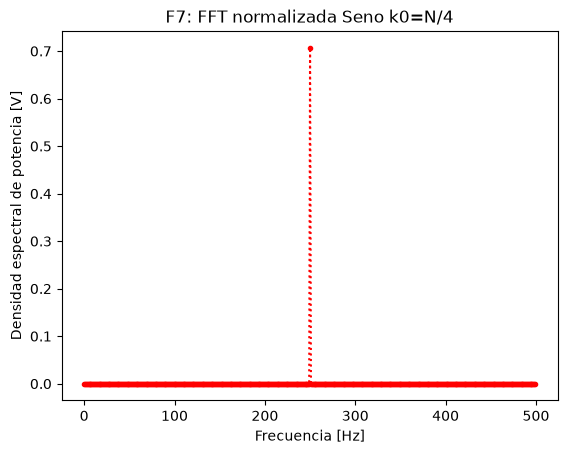

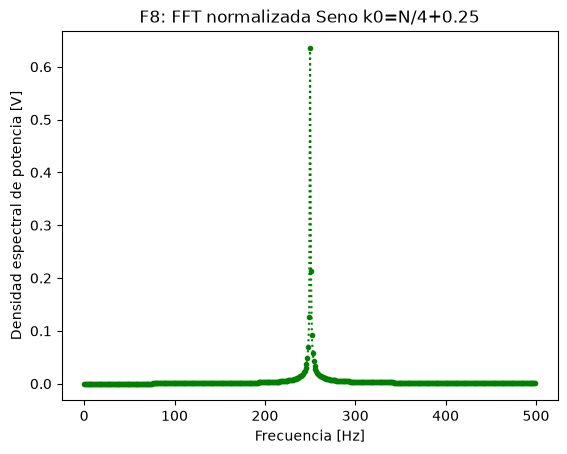

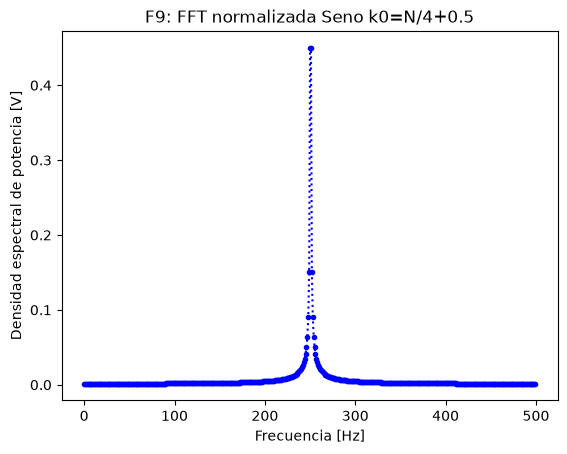

In [6]:
plt.figure(7)
plt.plot(freq1, fftsen1_abs[:N//2]/N, ":.", color="red")
plt.title("F7: FFT normalizada Seno k0=N/4")
plt.ylabel("Densidad espectral de potencia [V]")
plt.xlabel("Frecuencia [Hz]")

plt.figure(8)
plt.plot(freq2, fftsen2_abs[:N//2]/N,":.", color="green")
plt.title("F8: FFT normalizada Seno k0=N/4+0.25")
plt.ylabel("Densidad espectral de potencia [V]")
plt.xlabel("Frecuencia [Hz]")

plt.figure(9)
plt.plot(freq3, fftsen3_abs[:N//2]/N, ":.", color="blue")
plt.title("F9: FFT normalizada Seno k0=N/4+0.5")
plt.ylabel("Densidad espectral de potencia [V]")
plt.xlabel("Frecuencia [Hz]")

Esta vez, las figuras no se distinguen en gran medida como anteriormente. Sin embargo, una vez más el máximo de cada uno discierne como consecuencia de la organización de los puntos al alrededor de cada límite superior. Por lo tanto, se produce ese "puente" por debajo de los máximos de las Figuras 8 y 9, para compensar así la suma de la potencia total.

In [7]:
print(f"", np.max(fftsen1_abs[:N//2])/N, ">", np.max(fftsen2_abs[:N//2])/N, ">", np.max(fftsen3_abs[:N//2])/N)

 0.7071067811865476 > 0.6361198382805537 > 0.45016112002511277


A fin de corroborar la potencia previo y posterior a la aplicación de la Fast Fourier Transform, se empleará la identidad de Parseval.

In [8]:
Psen1=np.sum(sen1**2)/N
Pfft_sen1=np.sum(fftsen1_abs**2)/N**2
print("Potencia senoidal k0=N/4", np.round(Psen1,3), "--- Potencia senoidal transformada k0=N/4",np.round(Pfft_sen1,3))

Psen2=np.sum(sen2**2)/N
Pfft_sen2=np.sum(fftsen2_abs**2)/N**2
print("Potencia senoidal k0=N/4+0,25", np.round(Psen2,3), "--- Potencia senoidal transformada k0=N/4+0,25",np.round(Pfft_sen2,3))

Psen3=np.sum(sen3**2)/N
Pfft_sen3=np.sum(fftsen3_abs**2)/N**2
print("Potencia senoidal k0=N/4+0,5", np.round(Psen3,3), "--- Potencia senoidal transformada k0=N/4+0,5",np.round(Pfft_sen3,3))

Potencia senoidal k0=N/4 1.0 --- Potencia senoidal transformada k0=N/4 1.0
Potencia senoidal k0=N/4+0,25 0.999 --- Potencia senoidal transformada k0=N/4+0,25 0.999
Potencia senoidal k0=N/4+0,5 1.0 --- Potencia senoidal transformada k0=N/4+0,5 1.0


A continuación, se analizarán los efectos del zero padding. Al agregar un vector nulo de tamaño $9N$, mediante la función *concatenate*, cada senoidal contará ahora con $10N$ número de muestras totales, de las cuales únicamente los primeros 1000 puntos tendrán valores provistos de cada señal original.

In [9]:
ceros=np.zeros(9*N)
sen1_0=np.concatenate((sen1,ceros))
sen2_0=np.concatenate((sen2,ceros))
sen3_0=np.concatenate((sen3,ceros))

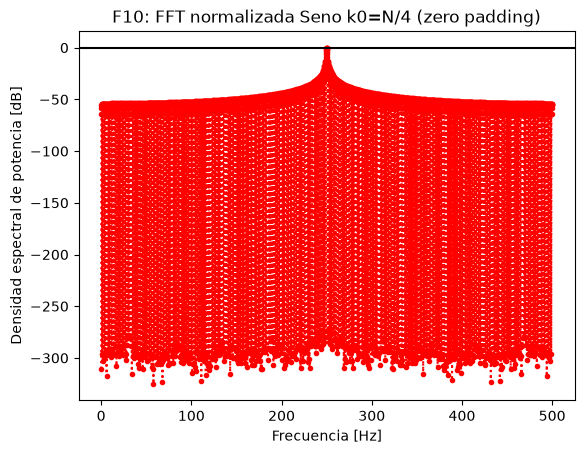

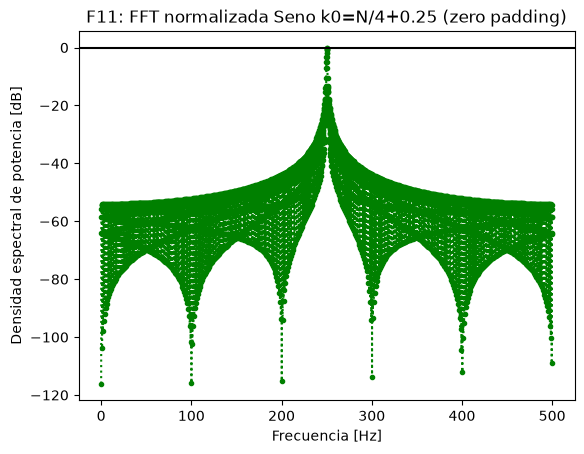

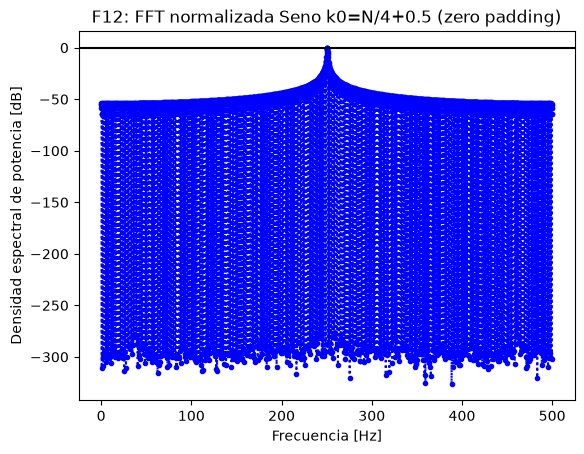

In [10]:
freq1, fftsen1_0_abs=fastfouriertrans(sen1_0, 10*N, fs)
freq2, fftsen2_0_abs=fastfouriertrans(sen2_0, 10*N, fs)
freq3, fftsen3_0_abs=fastfouriertrans(sen3_0, 10*N, fs)

ref=np.max(fftsen1_0_abs)
fftsen1_0_abs_dB=20*np.log10(fftsen1_0_abs/ref)
fftsen2_0_abs_dB=20*np.log10(fftsen2_0_abs/ref)
fftsen3_0_abs_dB=20*np.log10(fftsen3_0_abs/ref)

plt.figure(10)
plt.plot(freq1, fftsen1_0_abs_dB[:10*N//2], ":.", color="red")
plt.title("F10: FFT normalizada Seno k0=N/4 (zero padding)")
plt.ylabel("Densidad espectral de potencia [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.axhline(0,color="black")
plt.figure(11)
plt.plot(freq2, fftsen2_0_abs_dB[:10*N//2],":.", color="green")
plt.title("F11: FFT normalizada Seno k0=N/4+0.25 (zero padding)")
plt.ylabel("Densidad espectral de potencia [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.axhline(0,color="black")
plt.figure(12)
plt.plot(freq3, fftsen3_0_abs_dB[:10*N//2], ":.", color="blue")
plt.title("F12: FFT normalizada Seno k0=N/4+0.5 (zero padding)")
plt.ylabel("Densidad espectral de potencia [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.axhline(0,color="black")

Se realizó el mismo procedimiento previo, y se graficaron las densidades espectrales de potencia en decibeles. Aquí, la gran distinción se observa en la segunda figura de la sección, de la senoidal con $k_0=N/4+0,25$. Este aparenta tener una menor distribución de puntos que las otras dos funciones, teniendo la potencia más concentrada en valores más altos. A la vez, las señales de las Figuras 10 y 11 cuentan con una repartición de la potencia más amplia.
A causa de la gran cantidad de puntos añadidos, observamos esa "cortina" generada por el vector nulo.

Si graficamos las FFT normalizadas en función del voltajese, se observarán otros detalles:

Text(0.5, 0, 'Frecuencia [Hz]')

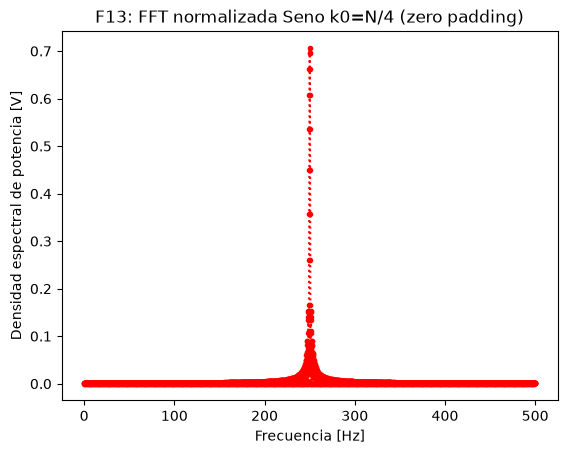

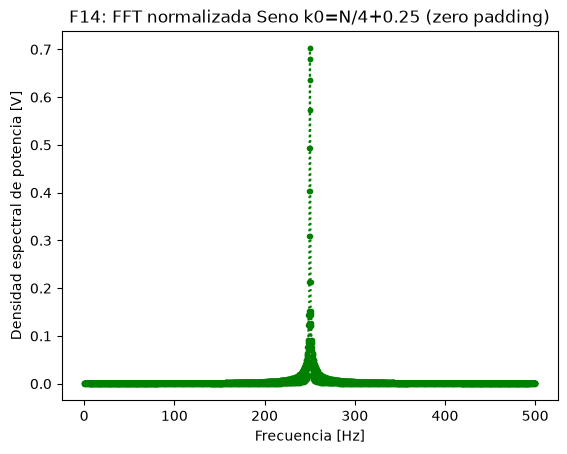

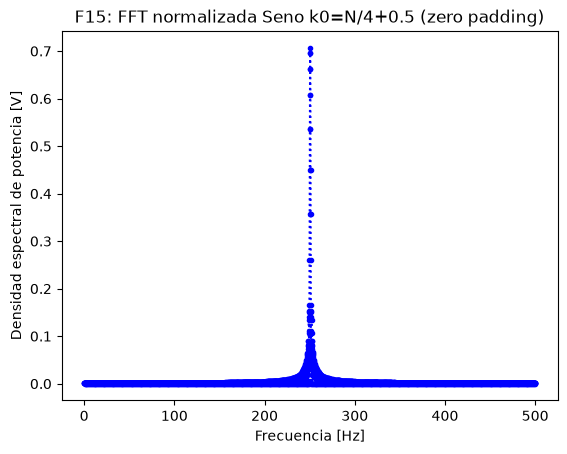

In [11]:
plt.figure(13)
plt.plot(freq1, fftsen1_0_abs[:10*N//2]/N, ":.", color="red")
plt.title("F13: FFT normalizada Seno k0=N/4 (zero padding)")
plt.ylabel("Densidad espectral de potencia [V]")
plt.xlabel("Frecuencia [Hz]")

plt.figure(14)
plt.plot(freq2, fftsen2_0_abs[:10*N//2]/N,":.", color="green")
plt.title("F14: FFT normalizada Seno k0=N/4+0.25 (zero padding)")
plt.ylabel("Densidad espectral de potencia [V]")
plt.xlabel("Frecuencia [Hz]")

plt.figure(15)
plt.plot(freq3, fftsen3_0_abs[:10*N//2]/N, ":.", color="blue")
plt.title("F15: FFT normalizada Seno k0=N/4+0.5 (zero padding)")
plt.ylabel("Densidad espectral de potencia [V]")
plt.xlabel("Frecuencia [Hz]")

Realizando ahora la compración con las Figuras 7, 8 y 9, mediante el zero padding se aprecian más puntos en la recta vertical, demostrando así sus secuelas en cuanto a la resolución de las frecuencias. Por otro lado, habrá que analizar la potencia. Para utilizar la identidad de Parseval, se requerirá realizar un cambio a la fórmula, ya que la totalidad de los puntos se vio modificada:
\begin{equation}
\frac{1}{N}\sum_{i=1}^{N-1}|x[n]|^2=\frac{1}{N}\frac{1}{10N}\sum_{i=1}^{N-1}|X[k]|^2
\end{equation}

In [12]:
Psen1_0=np.sum(sen1_0**2)/N
Pfft_sen1_0=np.sum(fftsen1_0_abs**2)/(N*10*N)
print("Potencia senoidal k0=N/4 (zero padding):", np.round(Psen1_0,3), "--- Potencia senoidal transformada k0=N/4 (zero padding):",np.round(Pfft_sen1_0,3))

Psen2_0=np.sum(sen2_0**2)/N
Pfft_sen2_0=np.sum(fftsen2_0_abs**2)/(N*10*N)
print("Potencia senoidal k0=N/4+0,25 (zero padding):", np.round(Psen2_0,3), "--- Potencia senoidal transformada k0=N/4+0,25 (zero padding)",np.round(Pfft_sen2_0,3))

Psen3_0=np.sum(sen3_0**2)/N
Pfft_sen3_0=np.sum(fftsen3_0_abs**2)/(N*10*N)
print("Potencia senoidal k0=N/4+0,5 (zero padding):", np.round(Psen3_0,3), "--- Potencia senoidal transformada k0=N/4+0,5 (zero padding):",np.round(Pfft_sen3_0,3))

Potencia senoidal k0=N/4 (zero padding): 1.0 --- Potencia senoidal transformada k0=N/4 (zero padding): 1.0
Potencia senoidal k0=N/4+0,25 (zero padding): 0.999 --- Potencia senoidal transformada k0=N/4+0,25 (zero padding) 0.999
Potencia senoidal k0=N/4+0,5 (zero padding): 1.0 --- Potencia senoidal transformada k0=N/4+0,5 (zero padding): 1.0


Entonces, finalmente corroboramos que la potencia de cada sistema se mantiene aún luego de la aplicación del zero padding.

#### Conclusiones
A partir a ciertos detalles implementados en la función sinusoidal, se consiguió una demostración ilustrativa del fenómeno del desparramo espectral. Como la potencia no se pudo concentrar en un bin en específico, se observó esa dispersión de puntos en los gráficos de PDS, cada una con diferentes caracterísitcas debido a la cercanía a los bins vecinos. Luego, mediante la identidad de Parseval se verificó la potencia de cada sistema antes y después de emplear la FFT. 

En cuanto al zero padding, se evidenciaron los drásticos cambios en las densidades espectrales de potencia, tanto en función de los decibeles como del voltaje. La gran cantidad de puntos nulos implementados al vector de la senoidal resultó en una gran cantidad de valores separados en un mayor espacio, y a la vez, en una mayor resolución entre puntos. También se ejecutó la función de la identidad de Parseval en este caso, y se obtuvo la misma potencia previa, indicando así, que el zero padding no la afecta en ese aspecto.